In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
ma_period = 200  # Period for moving average
std_dev_factor = 3  # Number of standard deviations for the bands
initial_capital = 100000  # Initial capital in USDT

# Load the OHLCV data (you can load from a CSV)
df = pd.read_csv('./btcusdt_1h.csv', parse_dates=['datetime'])
df = df.sort_values('datetime').reset_index(drop=True)

# Calculate the Moving Average (MA) and Standard Deviation
df['MA'] = df['close'].rolling(window=ma_period).mean()
df['Std_Dev'] = df['close'].rolling(window=ma_period).std()

# Calculate the Bollinger Bands
df['Upper_Band'] = df['MA'] + (std_dev_factor * df['Std_Dev'])
df['Lower_Band'] = df['MA'] - (std_dev_factor * df['Std_Dev'])

# Step 1: Generate Positions
df['Position'] = 0

for i in range(1, len(df)):
    current_price = df['close'].iloc[i]
    upper_band = df['Upper_Band'].iloc[i]
    lower_band = df['Lower_Band'].iloc[i]
    
    # Long condition: Price < lower_band (oversold)
    if current_price < lower_band:
        df.at[i, 'Position'] = 1  # Go long
    
    # Short condition: Price > upper_band (overbought)
    elif current_price > upper_band:
        df.at[i, 'Position'] = -1  # Go short
    
    #else: Neutral (Position remains 0)

df['Entry_Price']=0
for i in range(1, len(df)):
    # Entry conditions
    if df['close'].iloc[i] < df['Lower_Band'].iloc[i] and df['Position'].iloc[i-1] == 0:
        # Going long
        df['Position'].at[i] = 1  # Long position
        df['Entry_Price'].at[i] = df['close'].iloc[i] 

    elif df['close'].iloc[i] > df['Upper_Band'].iloc[i] and df['Position'].iloc[i-1] == 0:
        # Going short
        df['Position'].at[i] = -1  # Short position
        df['Entry_Price'].at[i] = df['close'].iloc[i] 

    # Exit conditions
    if df['Position'].iloc[i-1] == 1:  # Currently long
        # Exit long if close crosses lower band
        if df['close'].iloc[i] > df['Lower_Band'].iloc[i]:
            exit_price = df['close'].iloc[i] #exit_price
            if exit_price > df['Entry_Price'].iloc[i-1]:  # if exit_price > entry_price exit long
                df['Position'].at[i] = 0  # Exit position
            else:
                df['Entry_Price'].at[i]=df['Entry_Price'].at[i-1]
                df['Position'].at[i]=1
        else:
            df['Entry_Price'].at[i]=df['Entry_Price'].at[i-1]
            df['Position'].at[i]=1
    
    elif df['Position'].iloc[i-1] == -1:  # Currently short
        # Exit short if close crosses upper band
        if df['close'].iloc[i] < df['Upper_Band'].iloc[i] :
            exit_price = df['close'].iloc[i] 
            if exit_price < df['Entry_Price'].iloc[i-1]:  # if exit_price > entry_price exit short
                df['Position'].at[i] = 0  # Exit position
            else:
                df['Entry_Price'].at[i]=df['Entry_Price'].at[i-1]
                df['Position'].at[i]=-1
        else:
            df['Entry_Price'].at[i]=df['Entry_Price'].at[i-1]
            df['Position'].at[i]=-1


/tmp/ipykernel_230873/2595635372.py:44: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '11838.66' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df['Entry_Price'].at[i] = df['close'].iloc[i]


/tmp/ipykernel_230873/3207396601.py:20: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '2232.262013521046' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[i,'trades']=profit_loss
/tmp/ipykernel_230873/3207396601.py:21: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '8.438463466312902' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[i,'num_trades']=current_capital / entry_price
/tmp/ipykernel_230873/3207396601.py:22: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '11850.49866' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[i,'entry_price']=entry_price
/tmp/ipykernel_230873/3207396601.py:23: FutureWarning: 

Gross Profit: 98378.04
Net Profit: 95145.76
Gross Loss: -3232.29
Total Closed Trades: 1478.18
Number of Winning Trades: 1165.43
Number of Losing Trades: 312.75
Average Winning Trade (USDT): 93.26
Average Losing Trade (USDT): -10.67
Largest Winning Trade (USDT): 549.85
Largest Losing Trade (USDT): -20.41
Sharpe Ratio: 0.03
Sortino Ratio: 0.04


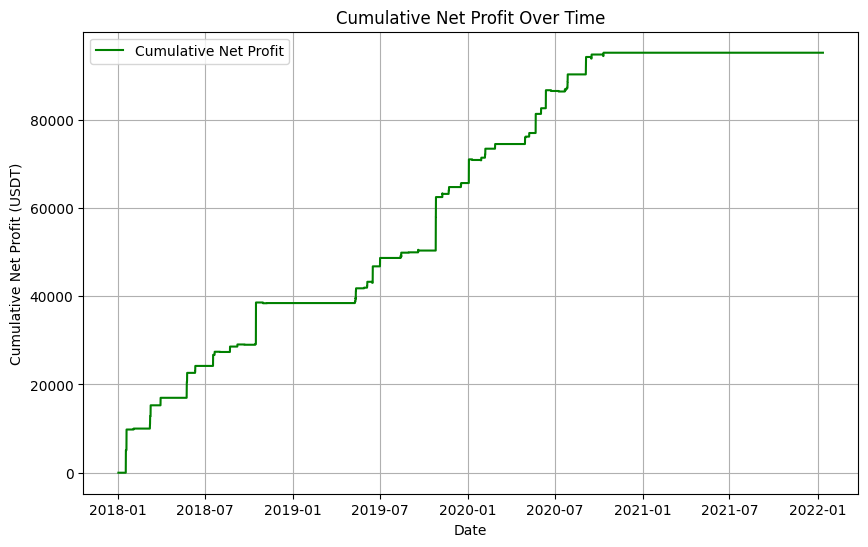

In [41]:
# Initialize variables for tracking trades and capital invested
df['trades']=0
df['num_trades']=0
df['entry_price']=0
df['exit_price']=0
trades = []
current_capital = initial_capital  # Track the current capital
prev_position = 0  # Track the current position (1 for long, -1 for short, 0 for neutral)
entry_price = None  # Track entry price for calculating profit/loss
brokerage = 0.1/100 #0.1%
# Iterate over the DataFrame to capture trade profits/losses
for i in range(1, len(df)):
    # Check if position changes
    if df['Position'].iloc[i] != prev_position:
        # Exiting long position
        if prev_position == 1:
            exit_price=(df['close'].iloc[i])*(1-brokerage)
            profit_loss = (exit_price - entry_price) * (current_capital / entry_price)
            trades.append(profit_loss)  # Append the realized profit/loss
            df.loc[i,'trades']=profit_loss
            df.loc[i,'num_trades']=current_capital / entry_price
            df.loc[i,'entry_price']=entry_price
            df.loc[i,'exit_price']=exit_price
            current_capital += profit_loss  # Update current capital
            prev_position = df['Position'].iloc[i]  # Update previoous position
            entry_price = None  # Reset entry price
        
        # Exiting short position
        elif prev_position == -1:
            exit_price=(df['close'].iloc[i])*(1+brokerage)
            profit_loss = (entry_price - exit_price) * (current_capital / entry_price)
            trades.append(profit_loss)  # Append the realized profit/loss
            df.loc[i,'trades']=profit_loss
            df.loc[i,'num_trades']=current_capital // entry_price
            df.loc[i,'entry_price']=entry_price
            df.loc[i,'exit_price']=exit_price
            current_capital += profit_loss  # Update current capital
            prev_position = df['Position'].iloc[i]  # Update previoous position
            entry_price = None  # Reset entry price
        
        # Entering long position
        if df['Position'].iloc[i] == 1:
            entry_price = (df['close'].iloc[i])*(1+brokerage)  # Capture entry price for long
            prev_position = 1  # Update to long position
        
        # Entering short position
        elif df['Position'].iloc[i] == -1:
            entry_price = (df['close'].iloc[i])*(1-brokerage)  # Capture entry price for short
            prev_position = -1  # Update to short position

winning_trades = df[df['trades'] > 0]
losing_trades = df[df['trades'] < 0]
# Sum the 'num_trades' column for all winning trades
num_winning_trades = winning_trades['num_trades'].sum()
num_losing_trades = losing_trades['num_trades'].sum()
# Count total trades and calculate other metrics
gross_profit = winning_trades['trades'].sum()
gross_loss = losing_trades['trades'].sum()

average_winning_trade = (winning_trades['trades']/winning_trades['num_trades']).mean() if num_winning_trades > 0 else 0
average_losing_trade =  (losing_trades['trades']/losing_trades['num_trades']).mean()if num_losing_trades > 0 else 0
largest_winning_trade = (winning_trades['trades']/winning_trades['num_trades']).max() if num_winning_trades > 0 else 0
largest_losing_trade = (losing_trades['trades']/losing_trades['num_trades']).min() if num_losing_trades > 0 else 0
net_profit=gross_profit+gross_loss

# Calculate cumulative net profit over time for plotting
df['Cumulative_Profit_Loss'] = df['trades'].cumsum().fillna(0)  # Fill missing values with 0
df['Returns'] = (df['Cumulative_Profit_Loss']+100000).pct_change().fillna(0)

# Risk-free rate 
risk_free_rate = 0  # 2% annually
days_in_year = 365  # Approximate number of trading days in a year
daily_risk_free_rate = (1 + risk_free_rate) ** (1 / days_in_year) - 1
# Calculate average daily return and standard deviation of daily returns
average_return = df['Returns'].mean()
std_dev_return = df['Returns'].std()
# Calculate the Sharpe Ratio
sharpe_ratio = (average_return - daily_risk_free_rate) / std_dev_return
#annual_returns=np.where((df['index']+1)%8760==0,df['Cumulative_Profit_Loss'].at[index]-df[''])
#sharpe_ratio=(df['Cumulative_Profit_Loss'].at[-1])
# Filter the negative returns (downside returns)
negative_returns = df[df['Returns'] < daily_risk_free_rate]['Returns']
# Calculate downside deviation (standard deviation of negative returns)
downside_deviation = negative_returns.std()
# Calculate the Sortino Ratio
sortino_ratio = (average_return - daily_risk_free_rate) / downside_deviation

# Output all metrics
metrics = {
    "Gross Profit": gross_profit,
    "Net Profit": net_profit,
    "Gross Loss": gross_loss,
    "Total Closed Trades": num_winning_trades+num_losing_trades,
    "Number of Winning Trades": num_winning_trades,
    "Number of Losing Trades": num_losing_trades,
    "Average Winning Trade (USDT)": average_winning_trade,
    "Average Losing Trade (USDT)": average_losing_trade,
    "Largest Winning Trade (USDT)": largest_winning_trade,
    "Largest Losing Trade (USDT)": largest_losing_trade,
    "Sharpe Ratio": sharpe_ratio,
    "Sortino Ratio": sortino_ratio
}

for metric, value in metrics.items():
    print(f"{metric}: {value:.2f}")

# Plot net profit over time
plt.figure(figsize=(10, 6))
plt.plot(df['datetime'], df['Cumulative_Profit_Loss'], label='Cumulative Net Profit', color='g')
plt.title('Cumulative Net Profit Over Time')
plt.xlabel('Date')
plt.ylabel('Cumulative Net Profit (USDT)')
plt.grid(True)
plt.legend()
plt.show()
